<a href="https://colab.research.google.com/github/AlonResearch/SNN-for-MI-EEG/blob/main/Notebooks/MI3_LSTM_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [99]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 500
LR = 1e-3
WEIGHT_DECAY = 1e-4
CLIP_NORM = 1.0
NUM_CLASSES = 3
CHANNELS = 62
LENGTH = 360
NUM_SEGMENTS = 10  # seq_len for LSTM
LSTM_HIDDEN = 128
BIDIRECTIONAL = True
DROPOUT = 0.3
REST_PERCENTAGE = 0.6 # 1 = 100% of rest trials, 0.5 = 50% of trials are taken
EARLY_STOP_PATIENCE = 15

In [102]:
# Update this path if your project structure is different
MAT_PATH = r"/content/sub-011_eeg90hz.mat"

In [54]:
# -----------------------
# Repro / device
# -----------------------
import numpy as np
import torch

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [55]:
import torch

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.9.0+cu126


In [109]:
import scipy.io as scio

mat = scio.loadmat(MAT_PATH)

all_data = mat['all_data'].astype(np.float32)
all_label = mat['all_label'].astype(np.int64)

# Check and transpose if (N, T, C)
# Note: `LENGTH` (T) and `CHANNELS` (C) are defined in config
if all_data.shape[1] == LENGTH and all_data.shape[2] == CHANNELS:
    all_data = np.transpose(all_data, (0, 2, 1)) # (N, C, T)

# --- Class balancing: only reduce the 'Rest' class based on REST_PERCENTAGE ---
np.random.seed(SEED)

# Identify indices for each class based on user's definition
idx_class_rest = np.where(all_label == 0)[0]
idx_class_elbow = np.where(all_label == 1)[0]
idx_class_hand = np.where(all_label == 2)[0]

# Determine the count of samples for each class
count_rest = len(idx_class_rest)
count_elbow = len(idx_class_elbow)
count_hand = len(idx_class_hand)
print(f"Initial counts: Rest (0): {count_rest}, Elbow (1): {count_elbow}, Hand (2): {count_hand}")

# Calculate the number of samples to take from the 'Rest' class (class 0) based on REST_PERCENTAGE
num_samples_rest_to_take = int(count_rest * REST_PERCENTAGE)
print(f"Adjusted Rest (0) samples (with REST_PERCENTAGE): {num_samples_rest_to_take}")

# Randomly sample indices for the 'Rest' class
np.random.shuffle(idx_class_rest)
sampled_idx_rest = idx_class_rest[:num_samples_rest_to_take]
print(f"Length of sampled_idx_rest: {len(sampled_idx_rest)}")

# Keep all samples for 'Elbow' and 'Hand' classes
sampled_idx_elbow = idx_class_elbow
print(f"Length of sampled_idx_elbow: {len(sampled_idx_elbow)}")

sampled_idx_hand = idx_class_hand
print(f"Length of sampled_idx_hand: {len(sampled_idx_hand)}")

# Concatenate the (reduced) Rest samples with the (full) Elbow and Hand samples
balanced_indices = np.concatenate([sampled_idx_rest, sampled_idx_elbow, sampled_idx_hand])
print(f"Total balanced_indices length: {len(balanced_indices)}")

data_np = all_data[balanced_indices]
labels_np = all_label[balanced_indices]

print("Data shape:", data_np.shape)
print("Labels shape:", labels_np.shape)
classes, counts = np.unique(labels_np, return_counts=True)
print("Classes:", classes, "Counts:", counts)

Initial counts: Rest (0): 365, Elbow (1): 300, Hand (2): 300
Adjusted Rest (0) samples (with REST_PERCENTAGE): 219
Length of sampled_idx_rest: 219
Length of sampled_idx_elbow: 300
Length of sampled_idx_hand: 300
Total balanced_indices length: 819
Data shape: (819, 62, 360)
Labels shape: (819, 1)
Classes: [0 1 2] Counts: [219 300 300]


In [110]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N,C,T)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (C,T)
        return x, self.y[idx]
def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = 0.0
    ys, ps = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        # Add unsqueeze(1) to make input (B, 1, C, T) for the CNN_LSTM_Segmented model
        logits = model(x.unsqueeze(1))
        loss = criterion(logits, y)

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()

        total_loss += loss.item()
        pred = torch.argmax(logits, dim=1)
        ys.append(y.detach().cpu().numpy())
        ps.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    acc = (y_true == y_pred).mean()
    mf1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / max(len(loader), 1), acc, mf1, y_true, y_pred

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    data_np, labels_np.squeeze(), test_size=0.2, random_state=SEED, stratify=labels_np.squeeze()
)
print("Train:", X_train.shape, np.bincount(y_train))
print("Test :", X_test.shape, np.bincount(y_test))

Train: (655, 62, 360) [175 240 240]
Test : (164, 62, 360) [44 60 60]


In [112]:
# Class weights (small but helps)
train_counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
class_weights = train_counts.sum() / (NUM_CLASSES * np.maximum(train_counts, 1.0))
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Class weights:", class_weights)

Class weights: [1.247619  0.9097222 0.9097222]


In [113]:
train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(EEGDataset(X_test,  y_test ), batch_size=BATCH_SIZE, shuffle=False)

In [114]:
xb, yb = next(iter(train_loader))
print("Batch x:", xb.shape, "Batch y:", yb.shape)

Batch x: torch.Size([64, 62, 360]) Batch y: torch.Size([64])


In [115]:
class CNNEncoder2D(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, 2)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.conv4 = nn.Conv2d(128, 256, 2)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.drop(x)
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.drop(x)
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.drop(x)
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))
        x = self.drop(x)
        return torch.flatten(x, 1)

In [116]:
class CNN_LSTM_Segmented(nn.Module):
    def __init__(self, channels, length, num_classes=3, num_segments=10, hidden=128, bidir=True, dropout=0.3):
        super().__init__()
        assert length % num_segments == 0, "length must be divisible by num_segments"
        self.channels = channels
        self.length = length
        self.num_segments = num_segments
        self.seg_len = length // num_segments

        self.encoder = CNNEncoder2D(dropout=dropout)

        with torch.no_grad():
            dummy = torch.zeros(2, 1, channels, self.seg_len)
            enc_dim = self.encoder(dummy).shape[1]

        self.lstm = nn.LSTM(
            input_size=enc_dim,
            hidden_size=hidden,
            num_layers=1,
            bidirectional=bidir,
            batch_first=True
        )

        out_dim = hidden * (2 if bidir else 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, num_classes)
        )

    def forward(self, x):
        # x: (B,1,C,T)
        B, _, C, T = x.shape
        x = x.view(B, 1, C, self.num_segments, self.seg_len).permute(0, 3, 1, 2, 4).contiguous()
        x = x.view(B * self.num_segments, 1, C, self.seg_len)

        feats = self.encoder(x)                      # (B*num_segments, F)
        feats = feats.view(B, self.num_segments, -1) # (B, seq_len, F)

        _, (h_n, _) = self.lstm(feats)
        if self.lstm.bidirectional:
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            last = h_n[-1]
        return self.head(last)

In [85]:
model = CNN_LSTM_Segmented(
    channels=CHANNELS,
    length=LENGTH,
    num_classes=NUM_CLASSES,
    num_segments=NUM_SEGMENTS,
    hidden=LSTM_HIDDEN,
    bidir=BIDIRECTIONAL,
    dropout=DROPOUT
).to(device)

In [117]:
print("Model ready. seq_len =", NUM_SEGMENTS, "seg_len =", LENGTH // NUM_SEGMENTS)

Model ready. seq_len = 10 seg_len = 36


In [118]:
# -----------------------
# Train / eval
# -----------------------
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [119]:
# Avoid verbose= (your torch complained)
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

In [120]:
def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = 0.0
    ys, ps = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        # Add unsqueeze(1) to make input (B, 1, C, T) for the CNN_LSTM_Segmented model
        logits = model(x.unsqueeze(1))
        loss = criterion(logits, y)

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()

        total_loss += loss.item()
        pred = torch.argmax(logits, dim=1)
        ys.append(y.detach().cpu().numpy())
        ps.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    acc = (y_true == y_pred).mean()
    mf1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / max(len(loader), 1), acc, mf1, y_true, y_pred

In [121]:
best_f1 = -1.0
best_state = None

In [122]:
best_f1 = -1.0
best_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader, train=True)
    te_loss, te_acc, te_f1, y_true_current, y_pred_current = run_epoch(test_loader, train=False)

    scheduler.step(te_f1)

    if te_f1 > best_f1:
        best_f1 = te_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        y_true, y_pred = y_true_current, y_pred_current # Store predictions from the best model
        patience_counter = 0 # Reset patience since improvement occurred
    else:
        patience_counter += 1 # Increment patience since no improvement

    if epoch == 1 or epoch % 5 == 0:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:03d} | train acc {tr_acc:.3f} f1 {tr_f1:.3f} | test acc {te_acc:.3f} f1 {te_f1:.3f} | lr {lr_now:.2e} | patience {patience_counter}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered after {patience_counter} epochs without improvement.")
        break

Epoch 001 | train acc 0.782 f1 0.796 | test acc 0.756 f1 0.774 | lr 1.00e-03
Epoch 005 | train acc 0.786 f1 0.801 | test acc 0.683 f1 0.694 | lr 1.00e-03
Epoch 010 | train acc 0.832 f1 0.845 | test acc 0.738 f1 0.760 | lr 5.00e-04
Epoch 015 | train acc 0.855 f1 0.867 | test acc 0.744 f1 0.754 | lr 5.00e-04
Epoch 020 | train acc 0.899 f1 0.908 | test acc 0.689 f1 0.710 | lr 2.50e-04
Epoch 025 | train acc 0.899 f1 0.908 | test acc 0.732 f1 0.750 | lr 1.25e-04
Epoch 030 | train acc 0.896 f1 0.904 | test acc 0.738 f1 0.754 | lr 6.25e-05
Epoch 035 | train acc 0.892 f1 0.900 | test acc 0.738 f1 0.754 | lr 6.25e-05
Epoch 040 | train acc 0.924 f1 0.930 | test acc 0.744 f1 0.760 | lr 3.13e-05
Epoch 045 | train acc 0.893 f1 0.902 | test acc 0.744 f1 0.760 | lr 1.56e-05
Epoch 050 | train acc 0.915 f1 0.922 | test acc 0.750 f1 0.766 | lr 1.56e-05
Epoch 055 | train acc 0.924 f1 0.930 | test acc 0.744 f1 0.761 | lr 7.81e-06
Epoch 060 | train acc 0.881 f1 0.891 | test acc 0.750 f1 0.767 | lr 3.91e-06

In [123]:
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

In [124]:
# Final evaluation
_, te_acc, te_f1, y_true, y_pred = run_epoch(test_loader, train=False)
print("\nFINAL")
print("Test accuracy:", te_acc)
print("Test macro-F1:", te_f1)


FINAL
Test accuracy: 0.774390243902439
Test macro-F1: 0.7927497789566754


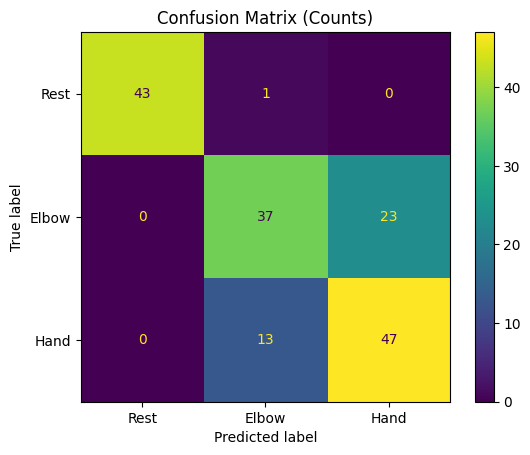

In [125]:
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
disp = ConfusionMatrixDisplay(cm, display_labels=["Rest","Elbow","Hand"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Counts)")
plt.show()

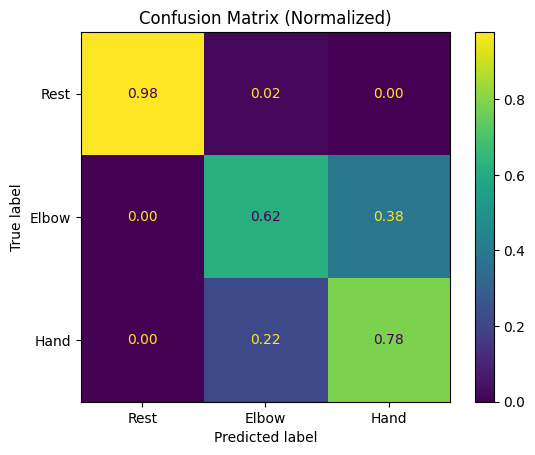

In [126]:
cmn = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
disp2 = ConfusionMatrixDisplay(cmn, display_labels=["Rest","Elbow","Hand"])
disp2.plot(values_format=".2f")
plt.title("Confusion Matrix (Normalized)")
plt.show()